In [1]:
import tensorflow as tf
import torch
import matplotlib.pyplot as plt

print(torch.cuda.is_available())

print(tf.config.list_physical_devices('GPU'))

plt.show()

2025-10-16 00:48:28.660267: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-16 00:48:28.882932: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-16 00:48:29.795165: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


True
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import torch.nn as nn
import torch
from torchinfo import summary

class MNISTNetwork_CNN_twostacked(nn.Module):
  def __init__(self):
    super().__init__()
    # Two conv layers of different kernel sizes
    self.conv1 = nn.Conv2d(1, 48, kernel_size=5, padding=2)  # First conv
    self.conv2 = nn.Conv2d(48, 82, kernel_size=3, padding=1) # Second conv

    self.relu1 = nn.ReLU()
    self.relu2 = nn.ReLU()
    # Compute the flattened dimension after both convs (no pooling)
    # Input: (1, 28, 28) → (16, 28, 28)
    self.fc1 = nn.Linear(82 * 28 * 28, 10)

    self.flatten = nn.Flatten()

  def forward(self, x, verbose = False):
    # Ensure input has correct shape
    x = torch.reshape(x, (-1, 1, 28, 28))
    
    # First convolution + ReLU
    x = self.relu1(self.conv1(x))
    # Second convolution + ReLU
    x = self.relu2(self.conv2(x))
    # Flatten and feed to linear layer
    x = self.flatten(x)
    logits = self.fc1(x)

    return logits
  
class MNISTNetwork_CNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv_1 = torch.nn.Conv2d( in_channels = 1, out_channels = 30, kernel_size = (3,3), stride = 1 )
    self.linear = torch.nn.Linear( in_features = 26*26*30, out_features = 10 )

  def forward(self, x, verbose = False):
    reshaped = torch.reshape( x, (-1, 1, 28, 28) )
    conv_results = self.conv_1( reshaped )
    conv_results = torch.nn.ReLU()( conv_results )
    flattened = torch.nn.Flatten()( conv_results )
    logits = self.linear( flattened )

    return logits

model = MNISTNetwork_CNN_twostacked()
model2 = MNISTNetwork_CNN()

# Print detailed summary
print(summary(model, input_size=(1, 1, 28, 28)))
print(summary(model2, input_size=(1, 1, 28, 28)))

Layer (type:depth-idx)                   Output Shape              Param #
MNISTNetwork_CNN_twostacked              [1, 10]                   --
├─Conv2d: 1-1                            [1, 48, 28, 28]           1,248
├─ReLU: 1-2                              [1, 48, 28, 28]           --
├─Conv2d: 1-3                            [1, 82, 28, 28]           35,506
├─ReLU: 1-4                              [1, 82, 28, 28]           --
├─Flatten: 1-5                           [1, 64288]                --
├─Linear: 1-6                            [1, 10]                   642,890
Total params: 679,644
Trainable params: 679,644
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 29.46
Input size (MB): 0.00
Forward/backward pass size (MB): 0.82
Params size (MB): 2.72
Estimated Total Size (MB): 3.54
Layer (type:depth-idx)                   Output Shape              Param #
MNISTNetwork_CNN                         [1, 10]                   --
├─Conv2d: 1-1                            [1, 30, 2

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Print progress every 100 batches
        if (batch_idx + 1) % 100 == 0:
            print(f"  Batch [{batch_idx+1}/{len(train_loader)}] - Loss: {loss.item():.4f}")
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc


def validate(model, val_loader, criterion, device):
    """Validate the model"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_loss = running_loss / len(val_loader)
    val_acc = 100 * correct / total
    return val_loss, val_acc
    return val_loss, val_acc

Using device: cuda

Model Summary:
Total parameters: 203,110

Starting training for 50 epochs...

Epoch [1/50]
  Batch [100/938] - Loss: 0.4418
  Batch [200/938] - Loss: 0.2569
  Batch [300/938] - Loss: 0.2563
  Batch [400/938] - Loss: 0.4105
  Batch [500/938] - Loss: 0.2230
  Batch [600/938] - Loss: 0.3379
  Batch [700/938] - Loss: 0.1732
  Batch [800/938] - Loss: 0.3081
  Batch [900/938] - Loss: 0.4524
  Train Loss: 0.3277 | Train Acc: 90.60%
  Val Loss:   0.2237 | Val Acc:   93.52%
  LR: 0.010000

  → Saved new best model (Val Acc: 93.52%)

Epoch [2/50]
  Batch [100/938] - Loss: 0.2077
  Batch [200/938] - Loss: 0.1923
  Batch [300/938] - Loss: 0.2129
  Batch [400/938] - Loss: 0.2035
  Batch [500/938] - Loss: 0.2233
  Batch [600/938] - Loss: 0.1921
  Batch [700/938] - Loss: 0.1010
  Batch [800/938] - Loss: 0.1217
  Batch [900/938] - Loss: 0.1044
  Train Loss: 0.1751 | Train Acc: 95.12%
  Val Loss:   0.1476 | Val Acc:   95.89%
  LR: 0.010000

  → Saved new best model (Val Acc: 95.89%)

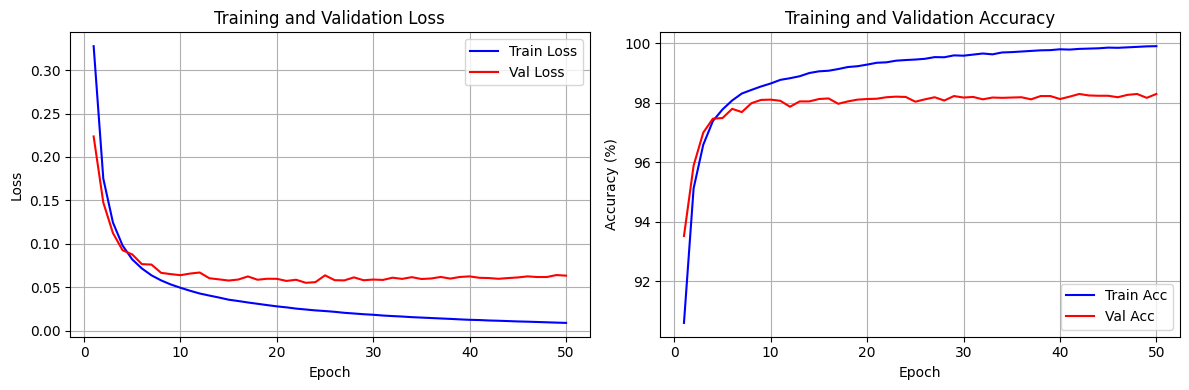

In [6]:
import time
import matplotlib.pyplot as plt

# Hyperparameters
batch_size = 64
learning_rate = 0.01
num_epochs = 50

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Data transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

# Load datasets
train_dataset = datasets.MNIST(root='./data', train=True, 
                                download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, 
                                download=True, transform=transform)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, 
                            shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, 
                        shuffle=False, num_workers=2)

# Initialize model, loss, and optimizer
model = MNISTNetwork_CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

print(f"\nModel Summary:")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"\nStarting training for {num_epochs} epochs...\n")

# Lists to track metrics
train_losses = []
train_accs = []
val_losses = []
val_accs = []

# Training loop
best_val_acc = 0.0
for epoch in range(num_epochs):
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, 
                                        optimizer, device)
    
    # Validate
    val_loss, val_acc = validate(model, test_loader, criterion, device)
    
    # Store metrics
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    # # Step scheduler
    # scheduler.step()
    
    # Print results
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}\n")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
        }, 'best_model.pth')
        print(f"  → Saved new best model (Val Acc: {val_acc:.2f}%)\n")

print(f"Training complete! Best validation accuracy: {best_val_acc:.2f}%")

# Load best model for final evaluation
checkpoint = torch.load('best_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
final_loss, final_acc = validate(model, test_loader, criterion, device)
print(f"\nFinal Test Accuracy: {final_acc:.2f}%")

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot loss
epochs_range = range(1, num_epochs + 1)
ax1.plot(epochs_range, train_losses, 'b-', label='Train Loss')
ax1.plot(epochs_range, val_losses, 'r-', label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

# Plot accuracy
ax2.plot(epochs_range, train_accs, 'b-', label='Train Acc')
ax2.plot(epochs_range, val_accs, 'r-', label='Val Acc')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
print("\nTraining curves saved to 'training_curves.png'")
plt.show()

Using device: cuda


Training: Baseline (Original)
Parameters: 679,644
  Epoch 2: Train Acc: 98.71% | Val Acc: 98.55%
  Epoch 4: Train Acc: 99.48% | Val Acc: 98.90%
  Epoch 6: Train Acc: 99.88% | Val Acc: 98.86%
  Epoch 8: Train Acc: 100.00% | Val Acc: 98.98%
  Epoch 10: Train Acc: 99.99% | Val Acc: 98.93%
Final Validation Accuracy: 98.93%

Training: Uniform Layers
Parameters: 540,362
  Epoch 2: Train Acc: 98.76% | Val Acc: 98.52%
  Epoch 4: Train Acc: 99.43% | Val Acc: 98.61%
  Epoch 6: Train Acc: 99.88% | Val Acc: 99.01%
  Epoch 8: Train Acc: 100.00% | Val Acc: 98.97%
  Epoch 10: Train Acc: 100.00% | Val Acc: 99.02%
Final Validation Accuracy: 99.02%

Training: Increasing Channels
Parameters: 781,226
  Epoch 2: Train Acc: 98.75% | Val Acc: 98.68%
  Epoch 4: Train Acc: 99.52% | Val Acc: 98.73%
  Epoch 6: Train Acc: 99.92% | Val Acc: 99.05%
  Epoch 8: Train Acc: 100.00% | Val Acc: 99.03%
  Epoch 10: Train Acc: 100.00% | Val Acc: 99.06%
Final Validation Accuracy: 99.06%

Training: Decrea

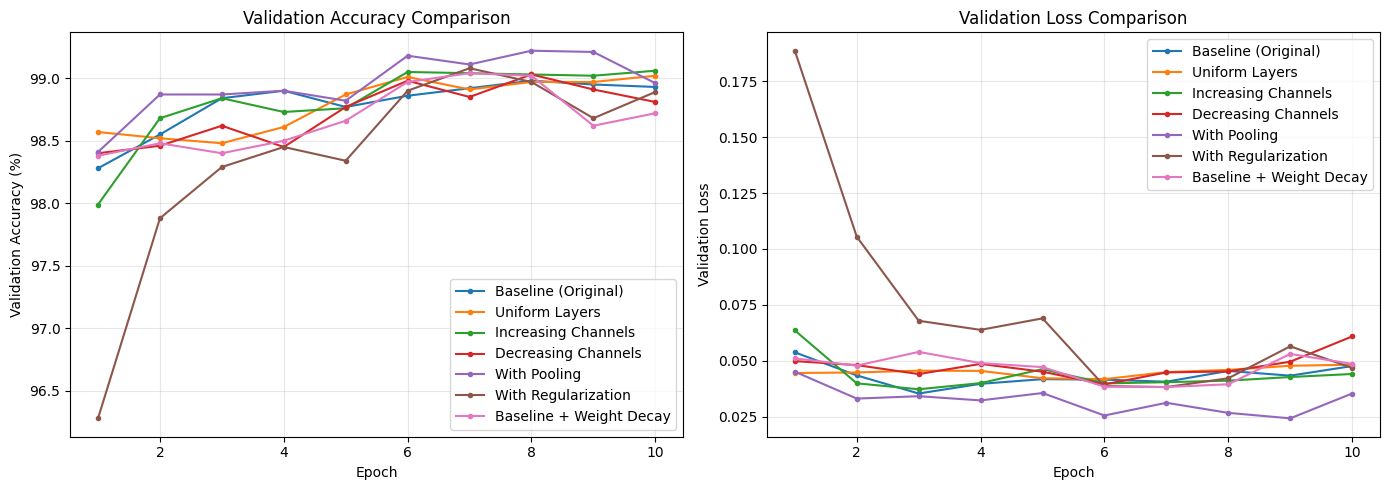


SUMMARY
Baseline (Original)            | Params:  679,644 | Acc: 98.93%
Uniform Layers                 | Params:  540,362 | Acc: 99.02%
Increasing Channels            | Params:  781,226 | Acc: 99.06%
Decreasing Channels            | Params:  281,066 | Acc: 98.81%
With Pooling                   | Params:   50,698 | Acc: 98.96%
With Regularization            | Params:  679,904 | Acc: 98.89%
Baseline + Weight Decay        | Params:  679,644 | Acc: 98.72%


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# ===================== ARCHITECTURE VARIANTS =====================

class BaselineCNN(nn.Module):
    """Original architecture - 2 stacked convs"""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 48, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(48, 82, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.relu2 = nn.ReLU()
        self.fc1 = nn.Linear(82 * 28 * 28, 10)
        self.flatten = nn.Flatten()

    def forward(self, x):
        x = torch.reshape(x, (-1, 1, 28, 28))
        x = self.relu1(self.conv1(x))
        x = self.relu2(self.conv2(x))
        x = self.flatten(x)
        return self.fc1(x)


class UniformLayersCNN(nn.Module):
    """Uniform channel sizes throughout"""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 64, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.relu2 = nn.ReLU()
        self.fc1 = nn.Linear(64 * 28 * 28, 10)
        self.flatten = nn.Flatten()

    def forward(self, x):
        x = torch.reshape(x, (-1, 1, 28, 28))
        x = self.relu1(self.conv1(x))
        x = self.relu2(self.conv2(x))
        x = self.flatten(x)
        return self.fc1(x)


class IncreasingCNN(nn.Module):
    """Gradually increasing channel sizes"""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(32, 96, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.relu2 = nn.ReLU()
        self.fc1 = nn.Linear(96 * 28 * 28, 10)
        self.flatten = nn.Flatten()

    def forward(self, x):
        x = torch.reshape(x, (-1, 1, 28, 28))
        x = self.relu1(self.conv1(x))
        x = self.relu2(self.conv2(x))
        x = self.flatten(x)
        return self.fc1(x)


class DecreasingCNN(nn.Module):
    """Decreasing channel sizes (pyramid)"""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 96, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(96, 32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.relu2 = nn.ReLU()
        self.fc1 = nn.Linear(32 * 28 * 28, 10)
        self.flatten = nn.Flatten()

    def forward(self, x):
        x = torch.reshape(x, (-1, 1, 28, 28))
        x = self.relu1(self.conv1(x))
        x = self.relu2(self.conv2(x))
        x = self.flatten(x)
        return self.fc1(x)


class WithPoolingCNN(nn.Module):
    """Using pooling to reduce spatial dimensions"""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5, padding=2)
        self.pool1 = nn.MaxPool2d(2, 2)  # 28x28 -> 14x14
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)  # 14x14 -> 7x7
        self.relu1 = nn.ReLU()
        self.relu2 = nn.ReLU()
        self.fc1 = nn.Linear(64 * 7 * 7, 10)
        self.flatten = nn.Flatten()

    def forward(self, x):
        x = torch.reshape(x, (-1, 1, 28, 28))
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        return self.fc1(x)


class WithRegularizationCNN(nn.Module):
    """Add dropout and batch normalization"""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 48, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm2d(48)
        self.conv2 = nn.Conv2d(48, 82, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(82)
        self.relu1 = nn.ReLU()
        self.relu2 = nn.ReLU()
        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(82 * 28 * 28, 10)
        self.flatten = nn.Flatten()

    def forward(self, x):
        x = torch.reshape(x, (-1, 1, 28, 28))
        x = self.relu1(self.bn1(self.conv1(x)))
        x = self.relu2(self.bn2(self.conv2(x)))
        x = self.flatten(x)
        x = self.dropout(x)
        return self.fc1(x)


# ===================== TRAINING FUNCTIONS =====================

def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    return running_loss / len(train_loader), 100 * correct / total


def validate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return running_loss / len(val_loader), 100 * correct / total


def train_model(model, train_loader, test_loader, device, num_epochs=10, lr=0.001, weight_decay=0.0):
    """Train a single model and return its history"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, test_loader, criterion, device)
        scheduler.step()
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        if (epoch + 1) % 2 == 0:
            print(f"  Epoch {epoch+1}: Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")
    
    return history


# ===================== EXPERIMENT RUNNER =====================

def run_experiments():
    # Setup
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}\n")
    
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    
    train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    
    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)
    
    # Define experiments
    experiments = [
        ("Baseline (Original)", BaselineCNN(), 0.0),
        ("Uniform Layers", UniformLayersCNN(), 0.0),
        ("Increasing Channels", IncreasingCNN(), 0.0),
        ("Decreasing Channels", DecreasingCNN(), 0.0),
        ("With Pooling", WithPoolingCNN(), 0.0),
        ("With Regularization", WithRegularizationCNN(), 0.0),
        ("Baseline + Weight Decay", BaselineCNN(), 1e-4),
    ]
    
    results = {}
    
    # Run experiments
    for name, model, weight_decay in experiments:
        print(f"\n{'='*60}")
        print(f"Training: {name}")
        model = model.to(device)
        param_count = sum(p.numel() for p in model.parameters())
        print(f"Parameters: {param_count:,}")
        print('='*60)
        
        history = train_model(model, train_loader, test_loader, device, 
                             num_epochs=10, weight_decay=weight_decay)
        
        final_val_acc = history['val_acc'][-1]
        results[name] = {
            'history': history,
            'params': param_count,
            'final_acc': final_val_acc
        }
        print(f"Final Validation Accuracy: {final_val_acc:.2f}%")
    
    # Plot comparison
    plot_comparison(results)
    
    # Print summary
    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    for name, result in results.items():
        print(f"{name:30s} | Params: {result['params']:8,} | Acc: {result['final_acc']:.2f}%")
    
    return results


def plot_comparison(results):
    """Plot all models' validation accuracy curves"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    for name, result in results.items():
        epochs = range(1, len(result['history']['val_acc']) + 1)
        ax1.plot(epochs, result['history']['val_acc'], label=name, marker='o', markersize=3)
        ax2.plot(epochs, result['history']['val_loss'], label=name, marker='o', markersize=3)
    
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Validation Accuracy (%)')
    ax1.set_title('Validation Accuracy Comparison')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Validation Loss')
    ax2.set_title('Validation Loss Comparison')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('architecture_comparison.png', dpi=150, bbox_inches='tight')
    print("\nComparison plot saved to 'architecture_comparison.png'")
    plt.show()


if __name__ == "__main__":
    results = run_experiments()